# CUSTOMER BEHAVIOUR ANALYSIS
**Main problem:** How can customer behaviour data be used to increase reorder revenue?

**Analytical Pipeline:**
1. EDA                 : Understand the data before modeling.
2. K-Means             : Segment/group customers by purchasing behaviour (In Progress)
3. Logistic Regression : Predict item-level reorder probability (In Progress)
4. Naive Bayes         : Auto-classify products into departments (In Progress)
5. Apriori / FP Growth : Discover product association rules for bundling (In Progress)

**Dataset:** Instacart Online Grocery Shopping Dataset 2017

**Author:** Aurelia Saskia

## 0. Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from mlxtend.preprocessing import TransactionEncoder

# Modeling
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Evaluation
from sklearn.metrics import (
    silhouette_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading & Preparation

To ensure the analysis is accurate, the master dataframe is divided into two for different context:
- **'df_train'**: Use 'order_products__train'. Used for prediction modeling (Logistic Regression) because it already have 'reordered' label as a valid ground truth.

- **'df_prior'**: Use 'order_products__prior'. Used for Segmentation, Classification and Association Rules because it covers all of customer's order history.

Each row in these dataframes represent a single product within a single order, along with the user, department, and aisle context.

In [2]:
df_aisles = pd.read_csv('data/aisles.csv')
df_departments = pd.read_csv('data/departments.csv')
df_orders = pd.read_csv('data/orders.csv')
df_products = pd.read_csv('data/products.csv')
df_order_products_train = pd.read_csv('data/order_products__train.csv')
df_order_products_prior = pd.read_csv('data/order_products__prior.csv')

print("Data loaded successfully!")

Data loaded successfully!


In [3]:
# Train Master DataFrame - for Prediction Modeling

df_train = (
    df_orders
    .merge(df_order_products_train, on='order_id', how='inner')  # merge line items with orders
    .merge(df_products, on='product_id', how='left')       # add product name
    .merge(df_departments, on='department_id', how='left') # add department name
    .merge(df_aisles, on='aisle_id', how='left')           # add aisle name
)

print(f"Train dataframe shape          : {df_train.shape}")
print(f"Unique users in train set      : {df_train['user_id'].nunique()}")
print(f"Unique products in train set   : {df_train['product_id'].nunique()}")
print(f"Unique orders in train set     : {df_train['order_id'].nunique()}")
print(f"Unique departments in train set: {df_train['department'].nunique()}")

Train dataframe shape          : (1384617, 15)
Unique users in train set      : 131209
Unique products in train set   : 39123
Unique orders in train set     : 131209
Unique departments in train set: 21


In [4]:
# Prior Master DataFrame - for Behaviour Analysis

df_prior = (
    df_orders
    .merge(df_order_products_prior, on='order_id', how='inner')  # merge line items with orders
    .merge(df_products, on='product_id', how='left')       # add product name
    .merge(df_departments, on='department_id', how='left') # add department name
    .merge(df_aisles, on='aisle_id', how='left')           # add aisle name
)

print(f"Prior dataframe shape          : {df_prior.shape}")
print(f"Unique users in prior set      : {df_prior['user_id'].nunique()}")
print(f"Unique products in prior set   : {df_prior['product_id'].nunique()}")
print(f"Unique orders in prior set     : {df_prior['order_id'].nunique()}")
print(f"Unique departments in prior set: {df_prior['department'].nunique()}")

Prior dataframe shape          : (32434489, 15)
Unique users in prior set      : 206209
Unique products in prior set   : 49677
Unique orders in prior set     : 3214874
Unique departments in prior set: 21


## 2. Exploratory Data Analysis (EDA)
**The Goals**:
- Validate data quality (nulls, duplictaes, impossible values).
- Understand data distribution (orders, products, departments).

### Inspect Data
Inspect what the data looks like and what datatype is used.

In [5]:
def inspect_data(df, name):
    print(f"--- {name} ---")
    print(df.head())
    print(df.info())
    print(df.describe())
    print("\n")

    return df

In [6]:
df_train = inspect_data(df_train, "Train Master DataFrame")
df_prior = inspect_data(df_prior, "Prior Master DataFrame")

--- Train Master DataFrame ---
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   1187899        1    train            11          4                  8   
1   1187899        1    train            11          4                  8   
2   1187899        1    train            11          4                  8   
3   1187899        1    train            11          4                  8   
4   1187899        1    train            11          4                  8   

   days_since_prior_order  product_id  add_to_cart_order  reordered  \
0                    14.0         196                  1          1   
1                    14.0       25133                  2          1   
2                    14.0       38928                  3          1   
3                    14.0       26405                  4          1   
4                    14.0       39657                  5          1   

                       product_name  aisle_id  department_id  department  \
0  

**DATA INSPECTION SUMMARY**
- df_train: smaller dataset, each row is a user's most recent order.
- df_prior: full purchase history, used for behavioral modeling.

**Key Observation from '.describe()'**
- 'add_to_cart_order': ranges from 1 to 80+. Items added late are likely impulse purchases.
- 'order_number': max is 100 (capped by the dataset). Shows data limitation.
- 'days_since_prior_order': mean ≈ 11 days, median ≈ 7 days (Right-skewed?) -> Most customer shops weekly, but there are some that shops monthly. NaN values are only for firt orders.

**No unexpected dtypes.**
All IDs are integers, names are objects. No columns were misread as wrong types during the merge.

### Check Data Quality
Check for empty value, duplicates, or impossible value

In [7]:
# Check Data Quality
def clean_data(df, name):
    print(f"Checking data quality for {name}...")

    # Check for missing values - before cleaning
    missing_before = df.isnull().sum()
    print(f"\nMissing values before cleaning:\n{missing_before}")

    # Fill missing values for days_since_prior_order with median
    median_value = df['days_since_prior_order'].median()
    df['days_since_prior_order'] = df['days_since_prior_order'].fillna(median_value)

    # Check for missing values - after cleaning
    missing_after = df.isnull().sum()
    print(f"\nMissing values after cleaning:\n{missing_after}")

    # ---------------------------------------------------------------------------------------

    # Check for duplicates - before cleaning
    dup = df.duplicated(subset=['order_id', 'product_id']).sum()
    dup_pct = dup / len(df) * 100
    print(f"\nDuplicate rows before cleaning: {dup}")

    if dup > 0:
        df = df.drop_duplicates(subset=['order_id', 'product_id'], keep='first')
        print(f"Duplicate rows removed: {dup}")

    if dup_pct > 1:
        print(f"Warning: {dup_pct:.2f}% of rows were duplicates. Recheck merge logic.")

    # Check for duplicates - after cleaning
    dup_after = df.duplicated(subset=['order_id', 'product_id']).sum()
    print(f"Duplicate rows after cleaning: {dup_after}")

    # ---------------------------------------------------------------------------------------
    
    # Check for impossible values
    print(f"\nImpossible Value")
    print(f"add_to_cart_order < 1: {(df['add_to_cart_order'] < 1).sum()}")
    print(f"days_since_prior_order > 30: {(df['days_since_prior_order'] > 30).sum()}\n")

    return df

In [8]:
df_train = clean_data(df_train, "Train Master DataFrame")
df_prior = clean_data(df_prior, "Prior Master DataFrame")

Checking data quality for Train Master DataFrame...

Missing values before cleaning:
order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_id                0
add_to_cart_order         0
reordered                 0
product_name              0
aisle_id                  0
department_id             0
department                0
aisle                     0
dtype: int64

Missing values after cleaning:
order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_id                0
add_to_cart_order         0
reordered                 0
product_name              0
aisle_id                  0
department_id             0
department                0
aisle                     0
dtype: int64

Duplicate rows b

### Explore Data
Things to check:
- Customer Behaviour (peak Shopping Hour, peak Shopping Day)
- Product Analysis (most reordered product)
- Correlation (most reordered department)

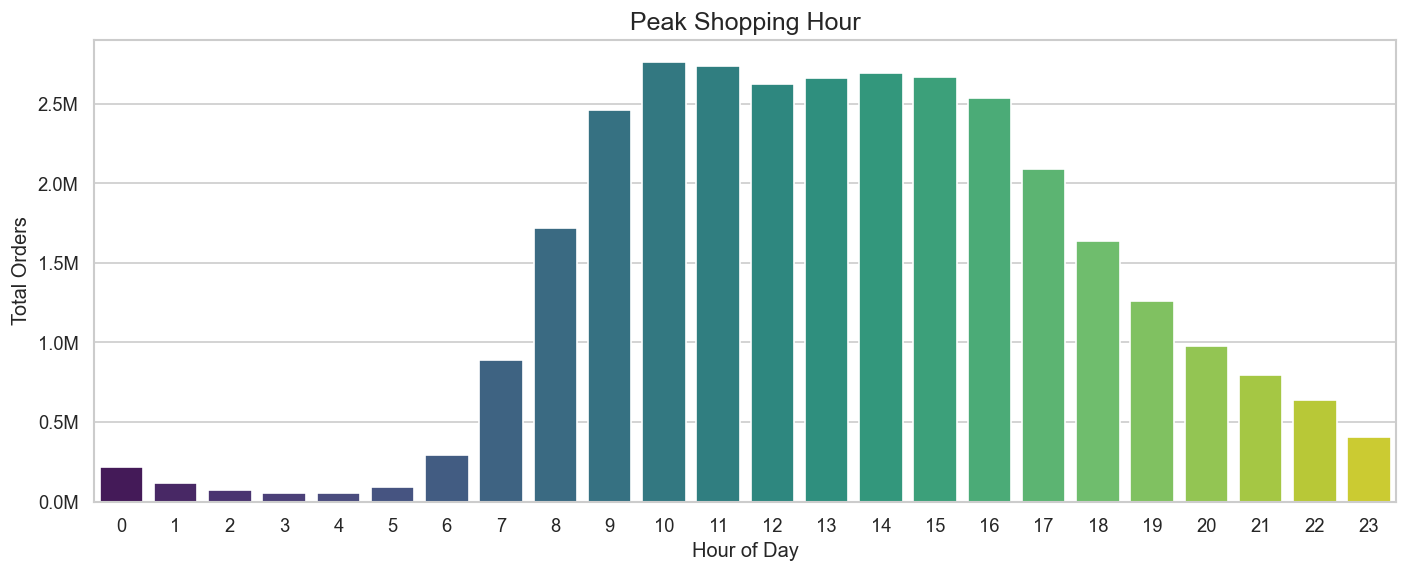

In [9]:
# Peak Shopping Hour
plt.figure(figsize=(14, 5))
ax = sns.countplot(x='order_hour_of_day', data=df_prior, palette='viridis')

# Change xlabel formatting for better readability
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)

plt.title('Peak Shopping Hour', fontsize=15)
plt.xlabel('Hour of Day')
plt.ylabel('Total Orders')
plt.show()

The graph shows that the peak shopping hour starts at 10:00 - 16:00. This shows that customers are most active in daytime. To further push purchase, a discount/promos push notification could be sent at around 9AM. Packaging and delivery staff also need to be optimized around this time of the day.

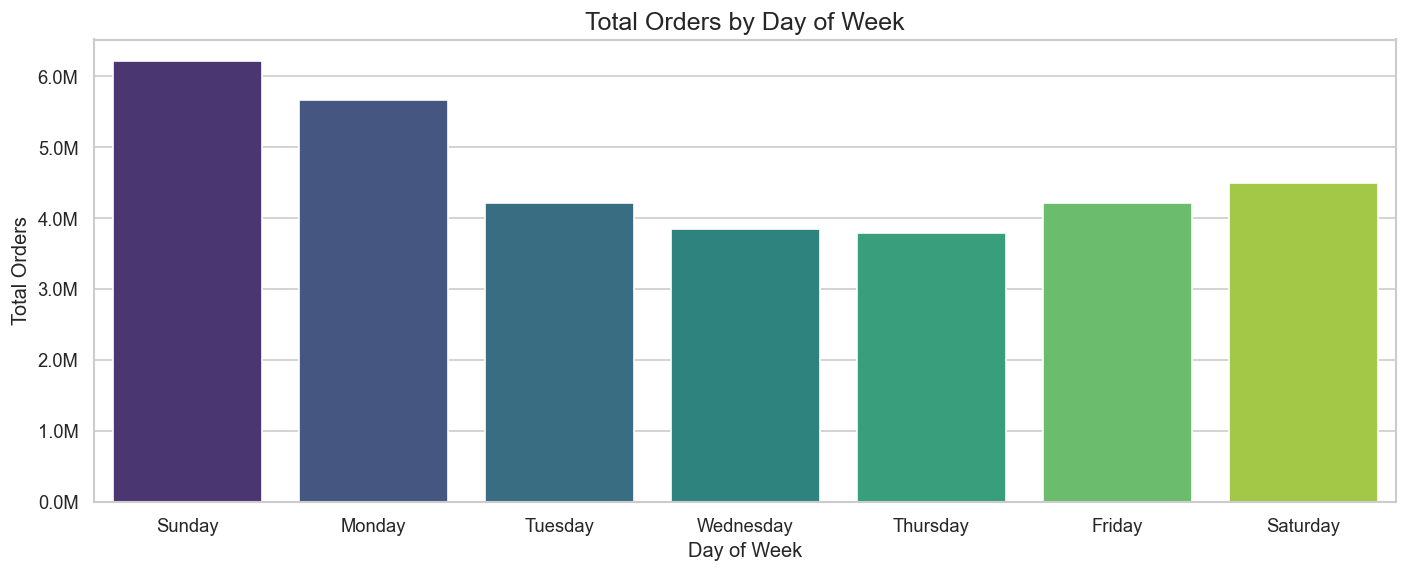

In [10]:
# Peak Shopping Day
day_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
df_prior['day_name'] = df_prior['order_dow'].map(day_map)
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

plt.figure(figsize=(14, 5))
ax = sns.countplot(x='day_name', data=df_prior, order=day_order, palette='viridis')

# Change xlabel formatting for better readability
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)

plt.title('Total Orders by Day of Week', fontsize=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Orders')
plt.show()

Highest total order by day in a week is on Sunday, followed by Monday. This shows that buyers tend to do weekly groceries on the start of every week. Setting up a early-week promotion around these days may help push the number of purchase further.

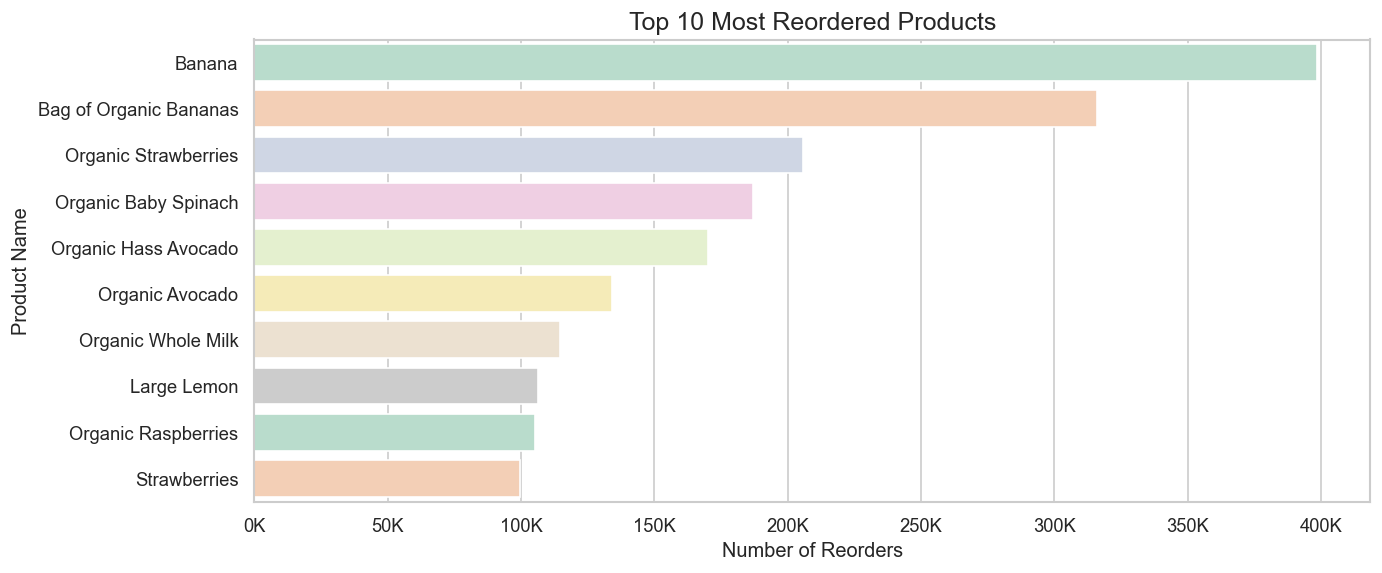

In [11]:
# Top Reordered Products
top_reordered_products = (
    df_prior[df_prior['reordered'] == 1]['product_name']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=top_reordered_products.values, y=top_reordered_products.index, palette='Pastel2')

# Change xlabel formatting for better readability
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x/1_000:.0f}K")
)

plt.title('Top 10 Most Reordered Products', fontsize=15)
plt.xlabel('Number of Reorders')
plt.ylabel('Product Name')
plt.show()

Note: The chart above shows reorder *volume*, not reorder *rate*.
High-volume products (e.g. Bananas) appear at the top partly due to the ordered number overall. Reorder rate by product is examined at the department level in the chart below.

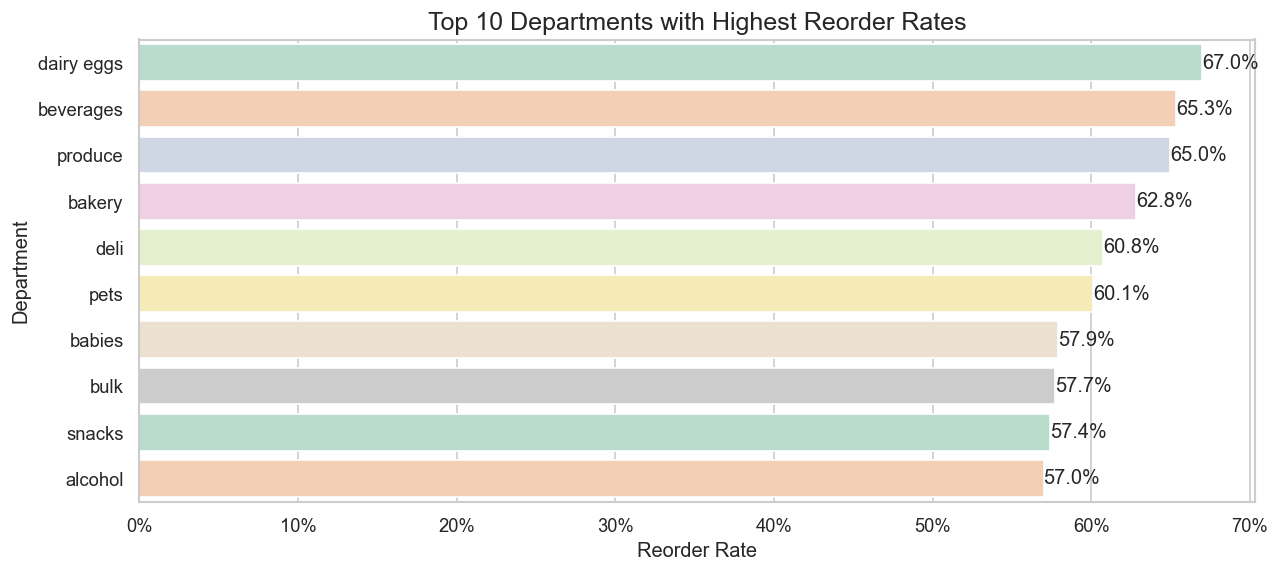

In [12]:
# Department with Highest Reorder Rate
dept_reorder_rate = (
    df_prior.groupby('department')['reordered']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=dept_reorder_rate.values, y=dept_reorder_rate.index, palette='Pastel2')

# Change xlabel formatting for better readability
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%")
)

# Add percentage labels to bars
for index, value in enumerate(dept_reorder_rate.values):
    plt.text(value, index, f"{value*100:.1f}%", va='center')

plt.title('Top 10 Departments with Highest Reorder Rates', fontsize=15)
plt.xlabel('Reorder Rate')
plt.ylabel('Department')
plt.show()

Based on the two graph above, the list of reordered product is dominated by fresh produce like Bananas and Organic Strawberries. The produce department also rank third based on reorder rates, proving that it's an essential department that maintain customer's loyalty.

Other department with high reorder rates, such as Dairy Eggs (67%) and Beverages (65.3%) also shows that stock & quality management in these departments would greatly affect customer in deciding to reorder.

As a recommendation, I suggest ensuring stocks are available for the products in the top reorder list and in the departments above, especially in the peak hours we found previously (10:00 - 16:00).